# CREDIT RISK ANALYSIS

#### In this project, we conducted a comprehensive predictive analytics study on a credit risk dataset containing 100,000 observations and 18 variables to classify loan outcomes as either Fully Paid or Charged Off. The work flow began with data inspection (shape, structure, missing values, data types), fallowed by systematic preprocessing: handling missing values, converting numeric columns, cleaining string-based numerical entries, removing high- cardinality and irrelevant variables (e.g.,IDs), encoding categorical variables using one-hot encoding, and mapping the target target variable into binary format (0/1). We performed exploratory data analysis including descriptive statistics, distribution analysis (histograms), outliers detection (boxplots), class distribution checks, group-based comparisons by loan status, and correlation analysis to understand inter-variable relationships. After preparing the dataset, we split it intı training (80%) and testing (20%) sets using stratified sampling to preserve class balance, aligned feature matrices, handled remaining missing values via median imputation, and applied feature scaling (StandardScaler) where required.

#### We then implemented three predictive analytics algoritms: Logistic Regression, Random Forest, and Support Vector Machine(SVM). For each model, we evaluated performance using Accuracy, Precision, Recall, ROC-AUC, Confusionmatrix, Classification Report, and ROC Curves to ensure a multi-metric assessment rather than relying solely on accuracy.

## DESCRIPTIVE ANALYTICS and DATA CLEANING and PROCESSING STEPS

##### To import the fundamental libraries required for data analysis and modeling : pandas for data manipulation, numpy for numerical operations, and matplotlib for visualization.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### To load the credit dataset into a pandas DataFrame and preview the first rows in order to understand the structure, variables, names, and overall data format.

In [5]:
df = pd.read_csv("C:/Users/Sami Sevdi/OneDrive/Masaüstü/data/credit.csv",sep=";",encoding="latin1",low_memory=False, index_col=0,)
df.head()

,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
Loan ID,,,,,,,,,,,,,,,,,,
14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,2.17.2026,NaN,6,1,228190,416746.0,1.0,0.0
4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,1.21.2026,8.0,35,0,229976,850784.0,0.0,0.0
4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,9.14.2026,29.0,18,1,297996,750090.0,0.0,0.0
77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.9,1.12.1900,NaN,9,0,256329,386958.0,0.0,0.0
d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.7,1.6.2026,NaN,15,0,253460,427174.0,0.0,0.0


##### The output displays the first observations of the dataset, showing both numerical and categorical variables, as well as the presence of missing values, confirming that data cleaning and preprocessing will be required before modeling.

# -------------------------------------------------------------------------------------------

##### To determine the dimensional structure of the dataset.

In [6]:
df.shape

(100000, 18)

##### The dataset contains 100,000 rows and 18 columns, indicating a relatively large sample size with multiple variables suitable for building robust predictive models.

# --------------------------------------------------------------------------------------------

##### To examine the dataset's structure, data types, and missing values before preprocessing and modeling.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 14dd8831-6af5-400b-83ec-68e61888a048 to c63916c6-6d46-47a9-949a-51d09af4414f
Data columns (total 18 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Customer ID                   100000 non-null  object 
 1   Loan Status                   100000 non-null  object 
 2   Current Loan Amount           100000 non-null  int64  
 3   Term                          100000 non-null  object 
 4   Credit Score                  80846 non-null   float64
 5   Annual Income                 80846 non-null   float64
 6   Years in current job          95778 non-null   object 
 7   Home Ownership                100000 non-null  object 
 8   Purpose                       100000 non-null  object 
 9   Monthly Debt                  100000 non-null  object 
 10  Years of Credit History       100000 non-null  object 
 11  Months since last delinquent  46859 non-null

##### The dataset including 6 float, 4 integer, and 8 categorical features.

# -------------------------------------------------------------------------------------------

##### To list all feature names in the dataset and clearly identify the target variable and predictor variables before modeling.

In [8]:
df.columns

Index(['Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

##### The dataset consists of 18 columns, including the target variable (Loan Status) and multiple nuerical and categorical predictors, conforming that both numerical and categorical preprocessing steps will be required before training predictive models.

# ------------------------------------------------------------------------------------

##### To generate descriptive statistics for all numerical cariables in order to understand central tendency, dispersion, and potential outliers before modeling.

In [9]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+05,80846.000000,8.084600e+04,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000
mean,1.176045e+07,1076.456089,1.378277e+06,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313
std,3.178394e+07,1475.403791,1.081360e+06,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182
min,1.080200e+04,585.000000,7.662700e+04,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


##### The summary shows sigbificant variability and skewness in financial variables, with very large maximum values compared to medians, indicating the presence of extreme values; additionally, some features such as Months since last delinquent have lower counts, conforming missing data that must be handled prior to training predictive models.

# ---------------------------------------------------------------------------------------

##### The purpose of of this step is to ensure that key financial and time-related variables (such as Monthly Debt and Years of Credit History) are correctly converted into numeric format so they can be properly used in statistical analysis and machine learning modeling.

In [10]:
df_clean=df.copy()
df_clean["Monthly Debt"]=pd.to_numeric(df_clean["Monthly Debt"], errors="coerce")
y=df_clean["Years of Credit History"].astype(str)
parts=y.str.split(".", expand=True)
mask_like_date=parts.shape[1] >= 3
if mask_like_date:
    df_clean["Years of Credit History"] = pd.to_numeric(parts[0].fillna("") + "." + parts[1].fillna(""), errors="coerce")
else:
    df_clean["Years of Credit History"] = pd.to_numeric(df_clean["Years of Credit History"], errors="coerce")
df_clean.dtypes

Customer ID                      object
Loan Status                      object
Current Loan Amount               int64
Term                             object
Credit Score                    float64
Annual Income                   float64
Years in current job             object
Home Ownership                   object
Purpose                          object
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts           int64
Number of Credit Problems         int64
Current Credit Balance            int64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

##### The resulting dtypes output confirms that previously problematic columns have been successfully converted to numeric types, meaning the dataset is now structurally consistent and ready for statistical analysis and predictive modeling.

# --------------------------------------------------------------------------------------

##### The purpose of this step is to identify and quantify missing values in the dataset in order to understand the extent of data incompleteness before appling preprocessing or modelling techniques.

In [11]:
missing_count= df_clean.isna().sum().sort_values(ascending=False)
missing_ratio= (df_clean.isna().mean() * 100).sort_values(ascending=False)
missing_df=pd.DataFrame({"missing_count": missing_count,"missing_%" : missing_ratio.round(2)})
missing_df


,missing_count,missing_%
Months since last delinquent,53141,53.14
Annual Income,19154,19.15
Credit Score,19154,19.15
Years in current job,4222,4.22
Bankruptcies,204,0.20
Tax Liens,10,0.01
Monthly Debt,5,0.00
Maximum Open Credit,2,0.00
Loan Status,0,0.00
Customer ID,0,0.00


##### The results show that "Months since last delinquent" has a very high missing rate (53.14%), while Annual Income and Credit Score each have about 19% missing values; most other variables have negligible or no missing data, indicating that missing-value handling should primarily focus on these key financial risk indicators before model training.

# -------------------------------------------------------------------------------------------

##### The purpose of this step is to examine the statistical distribution of numerical variables in the dataset in order to understand their central tendency, dispersion, and potential outliers before modeling.

In [12]:
num_cols= df_clean.select_dtypes(include=[np.number]).columns.tolist()
df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,100000.0,1.176045e+07,3.178394e+07,10802.0,179652.00,312246.00,524942.00,1.000000e+08
Credit Score,80846.0,1.076456e+03,1.475404e+03,585.0,705.00,724.00,741.00,7.510000e+03
Annual Income,80846.0,1.378277e+06,1.081360e+06,76627.0,848844.00,1174162.00,1650663.00,1.655574e+08
Monthly Debt,99995.0,1.847334e+04,1.217460e+04,0.0,10214.59,16221.44,24012.20,4.358433e+05
Years of Credit History,100000.0,6.118554e+00,7.176952e+00,1.1,2.13,5.14,7.22,7.050000e+01
Months since last delinquent,46859.0,3.490132e+01,2.199783e+01,0.0,16.00,32.00,51.00,1.760000e+02
Number of Open Accounts,100000.0,1.112853e+01,5.009870e+00,0.0,8.00,10.00,14.00,7.600000e+01
Number of Credit Problems,100000.0,1.683100e-01,4.827050e-01,0.0,0.00,0.00,0.00,1.500000e+01
Current Credit Balance,100000.0,2.946374e+05,3.761709e+05,0.0,112670.00,209817.00,367958.75,3.287897e+07
Maximum Open Credit,99998.0,7.607984e+05,8.384503e+06,0.0,273438.00,467874.00,782958.00,1.539738e+09


##### The statistics reveal strong skewness and extreme maximum values in variables such as Current Loan Amount, Annual Income, Maximum Open Credit, and Current Credit Balance, indicating the presence of outliers; meanwhile, variables like Credit Score and Years of Credit History show more stable distributions, suggesting that scaling and possible outlier treatment are important before applying predictive models.

# -------------------------------------------------------------------------------------------

##### The purpose of this step is to visually examine the distribution of each numerical variable using histograms in order to detect skewness, outliers, and overall distribution patterns before modeling.

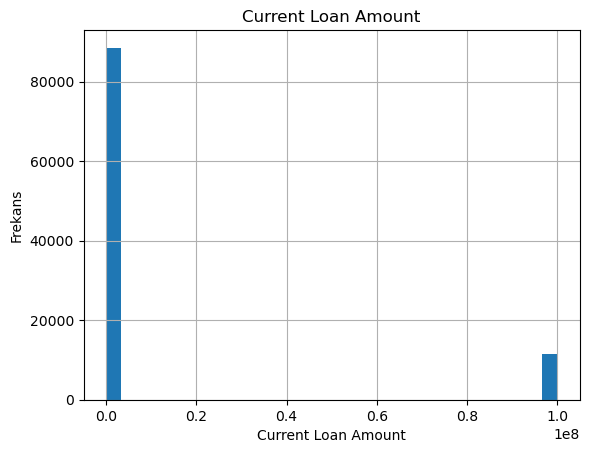

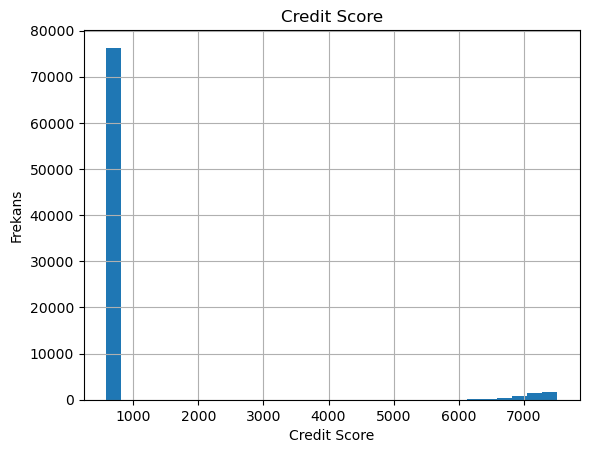

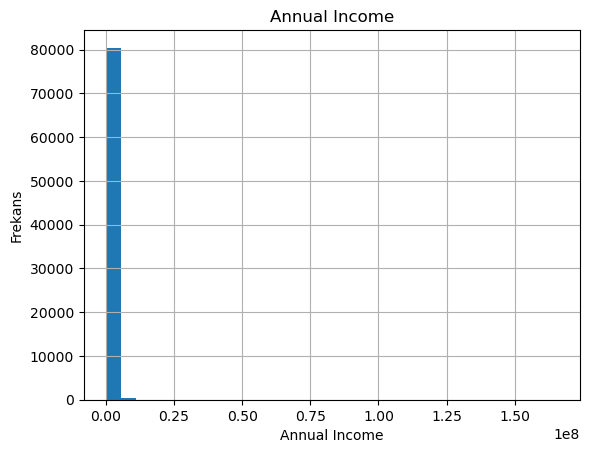

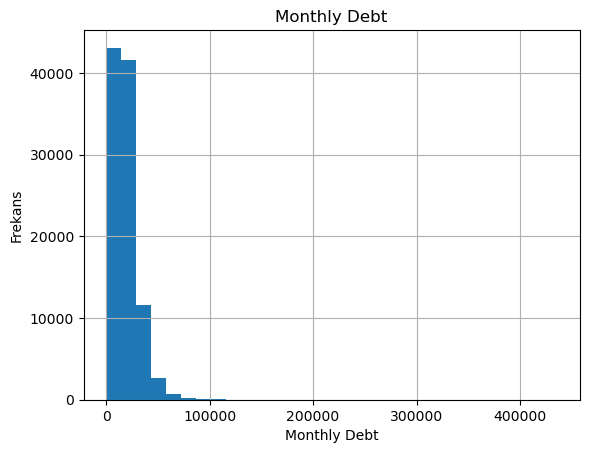

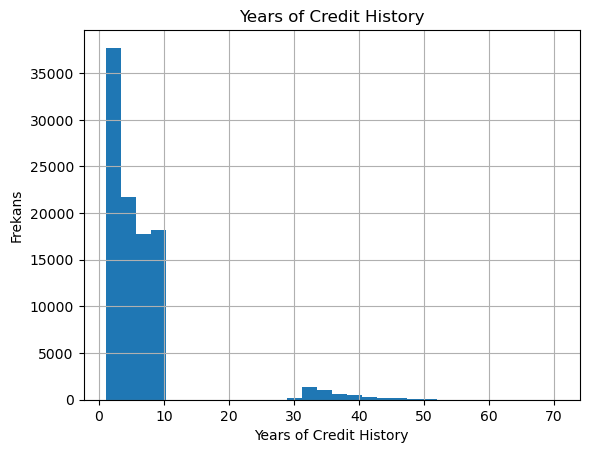

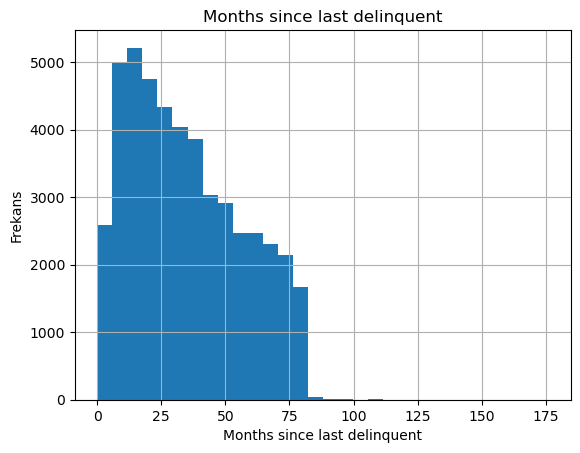

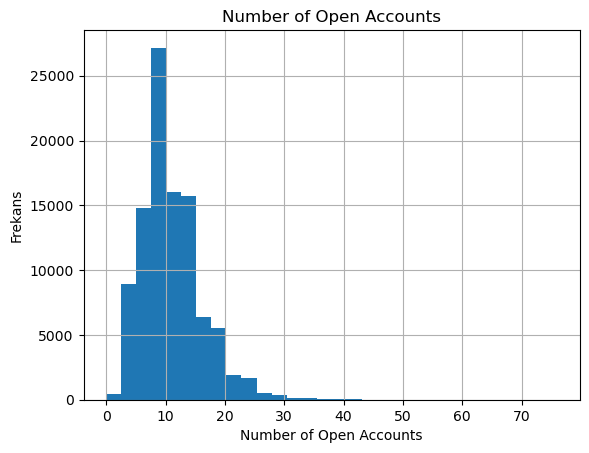

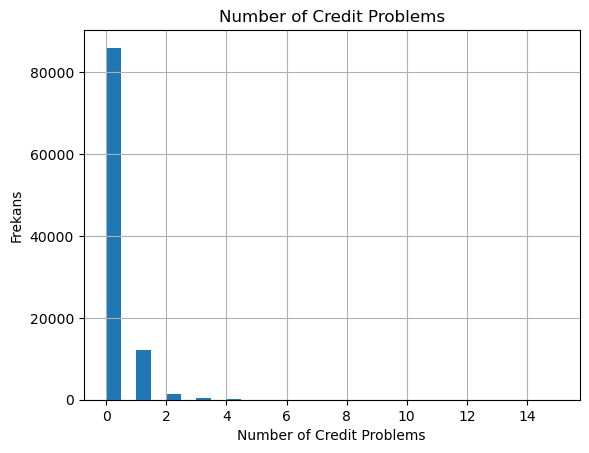

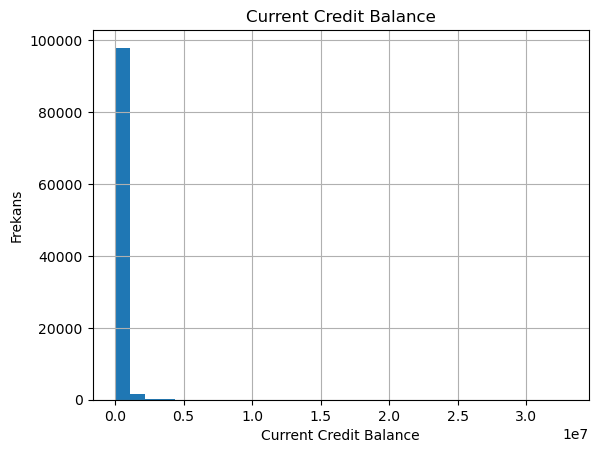

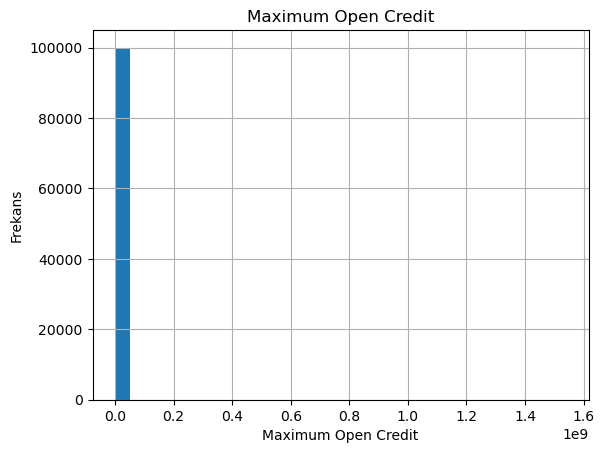

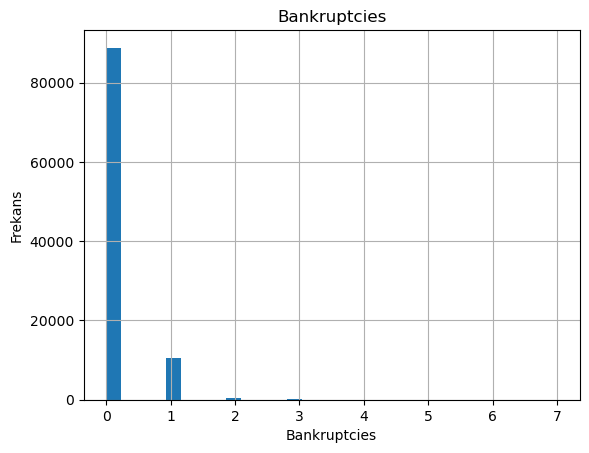

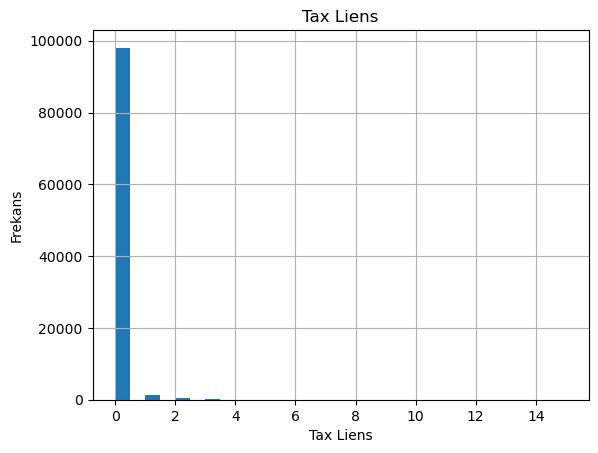

In [13]:
for col in num_cols:
    plt.figure()
    df_clean[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frekans")
    plt.show()

##### The dataset contains large-scale financial variables with skewed distributions, noticeable outliers, and some missing values; overall, the structure is suitable for predictive modeling after appropriate preprocessing and cleaning steps.

# -----------------------------------------------------------------------------------

##### The purpose of this step is to detect outliers and examine the dispersion of numerical variables using boxplots, allowing a clearer visualization of extreme values and distribution spread.

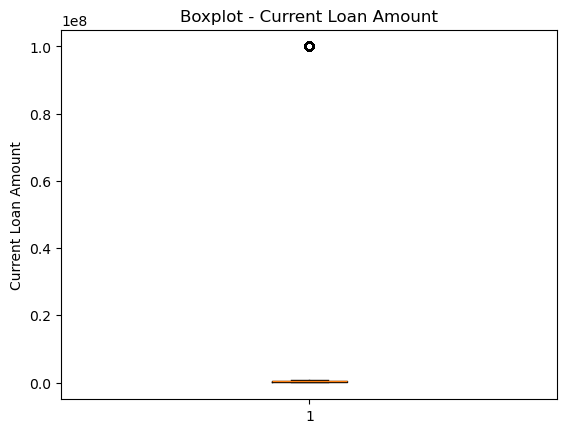

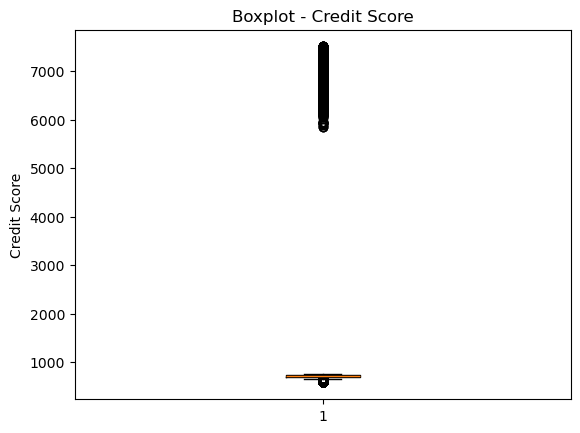

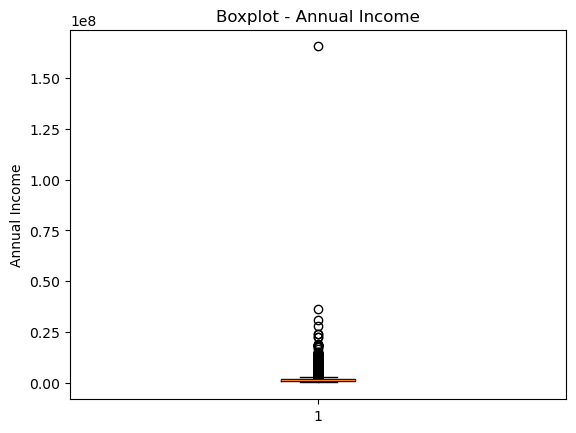

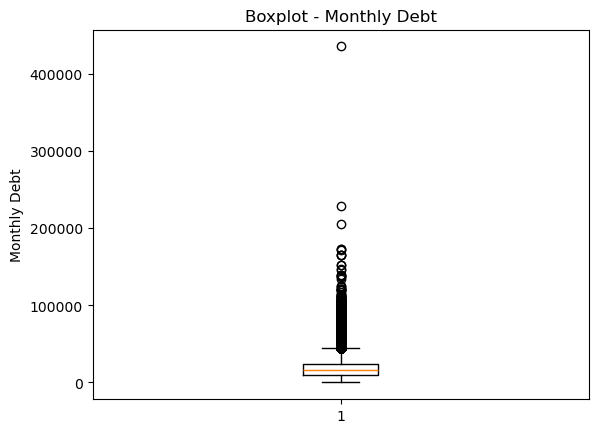

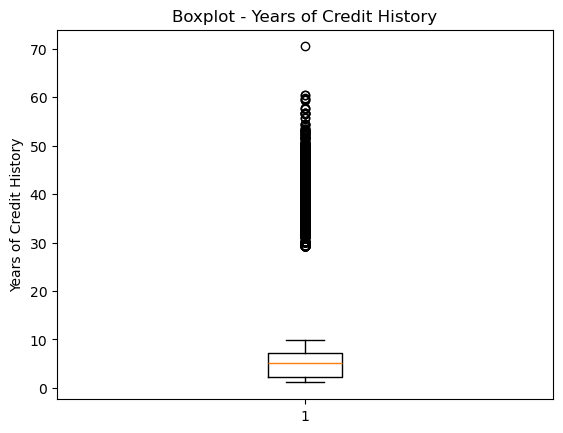

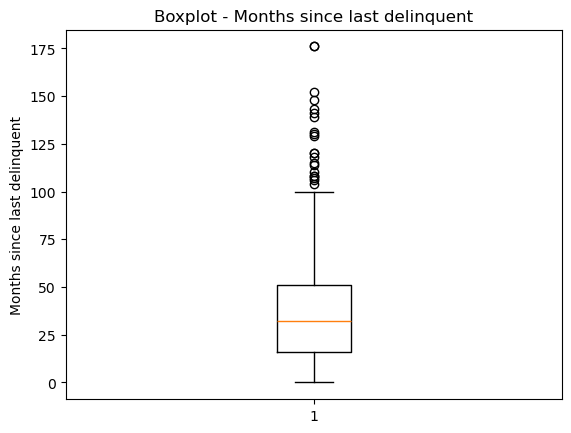

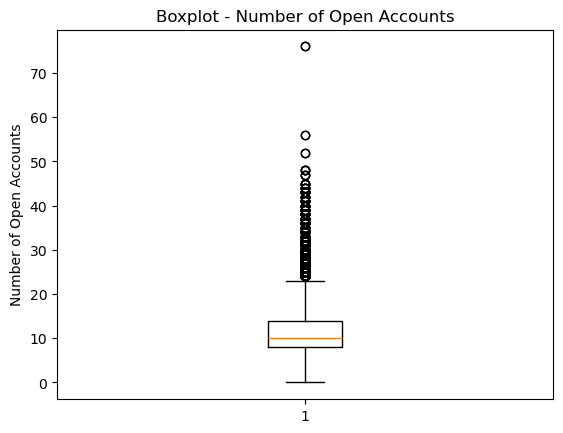

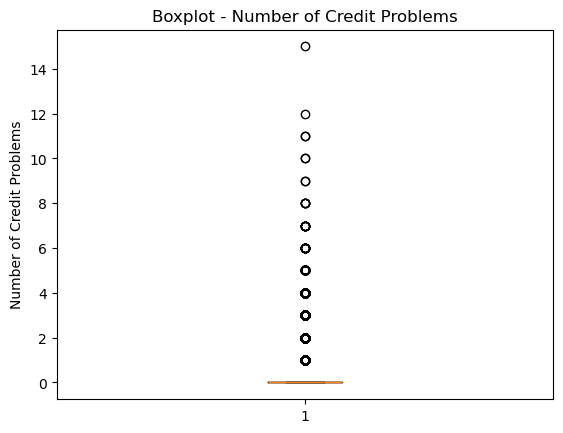

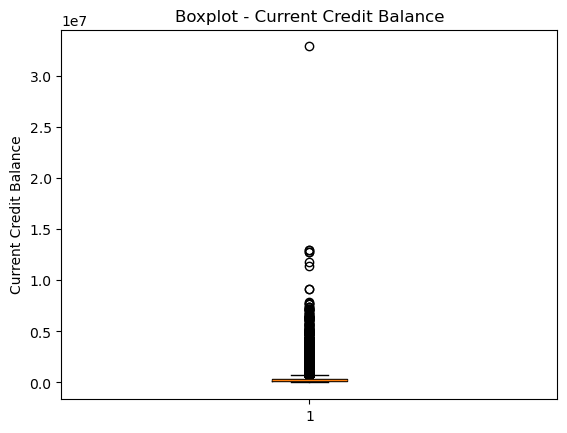

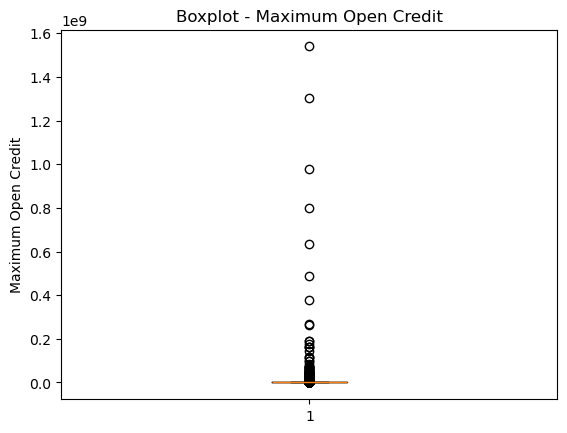

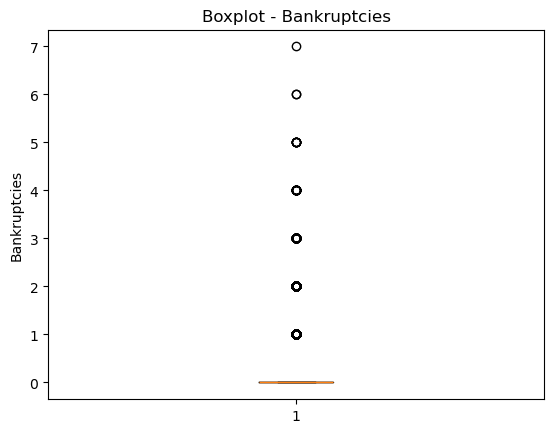

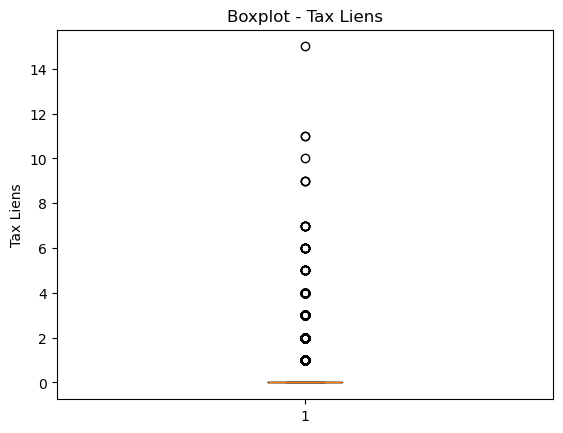

In [14]:
for col in num_cols:
    plt.figure()
    plt.boxplot(df_clean[col].dropna(), vert=True)
    plt.title(f"Boxplot - {col}")
    plt.ylabel(col)
    plt.show()

##### The boxplots reveal significant outliers and high dispersionin financial variables, indicating skewed distributions that may influence model performance and require careful handling.

# ---------------------------------------------------------------------------------------

##### The purpose of this step is to analyze categorical variables by identifying the number of unique categories and examining the frequency distribution of the most common values in each feature.

In [15]:
cat_cols= df_clean.select_dtypes(include=["object"]).columns.tolist()
for col in cat_cols:
    print("\n" , "="*60)
    print(f"{col} - unique: {df_clean[col].nunique(dropna=True)}")
    print(df_clean[col].value_counts(dropna=False).head(10))


Customer ID - unique: 81999
Customer ID
54f57722-2473-4dd8-b69b-82b5b0c1c9f9    2
cbe53e22-ba67-4eaf-a4fb-c5acdd12ec66    2
9baf6d5d-f744-4332-abb0-e939b75cde40    2
967e8733-7189-49b7-a3ab-6a1d0e1abdac    2
3ec886e7-f15d-4c35-83d0-bdec4817ae4b    2
b6f9e737-6609-45fd-8d6c-37b1b64c45df    2
cdb9037a-a7e4-49e5-ace2-61cb3df0e1e0    2
2b8d9ed7-d6d4-491e-82f9-f5bee3bd9408    2
6cfb0765-7cd8-4ef5-aa6e-f935caf57cf0    2
86d02184-ce07-4f47-9f68-45743fa29ced    2
Name: count, dtype: int64

Loan Status - unique: 2
Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64

Term - unique: 2
Term
Short Term    72208
Long Term     27792
Name: count, dtype: int64

Years in current job - unique: 11
Years in current job
10+ years    31121
2 years       9134
3 years       8169
< 1 year      8164
5 years       6787
1 year        6460
4 years       6143
6 years       5686
7 years       5577
8 years       4582
Name: count, dtype: int64

Home Ownership - unique: 4
Home Ownership
Home

##### The dataset contains meaningful categorical structure: Loan Status is binary (Fully paid vs Charged Off), Term has two categories (Short/Long), and Years in current job has 11 level with concentration "10+ years"; additionally, Customer ID has very high uniqueness, indicating it is an identifier rather than a feature and should not be used for modeling.

# ----------------------------------------------------------------------------------------

##### The purpose of this step is to examine the distribution of the target variable (Loan Status) in order to understand class balance before modeling.

In [16]:
df_clean["Loan Status"].value_counts(dropna=False)

Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64

##### The dataset is moderately imbanced : 77,361 Fully Paid vs 22,639 Charged Off.

# ------------------------------------------------------------------------------

##### The purpose of this step is to compare numerical feature distributions across different loan status groups in order to identify structural differences between classes.

In [17]:
group_stats=df_clean.groupby("Loan Status")[num_cols].agg(["count", "mean" , "median"]).round(2)
group_stats

Current Loan Amount                        Credit Score           \
                          count         mean    median        count     mean   
Loan Status                                                                    
Charged Off               22639    324975.23  286726.0        17210  2402.30   
Fully Paid                77361  15106935.34  321266.0        63636   717.89   

                   Annual Income                        Monthly Debt  ...  \
            median         count        mean     median        count  ...   
Loan Status                                                           ...   
Charged Off  730.0         17210  1267789.54  1085812.0        22638  ...   
Fully Paid   723.0         63636  1408157.16  1213026.5        77357  ...   

            Current Credit Balance Maximum Open Credit                       \
                            median               count       mean    median   
Loan Status                                                                   
Charged Off               213978.0               22637  630533.79  443344.0   
Fully Paid                208411.0               77361  798915.77  475288.0   

            Bankruptcies              Tax Liens               
                   count  mean median     count  mean median  
Loan Status                                                   
Charged Off        22589  0.11    0.0     22639  0.03    0.0  
Fully Paid         77207  0.12    0.0     77351  0.03    0.0  

[2 rows x 36 columns]

##### Charged Off loans generally show lower credit scores and different financial profile patterns, while Full paid loans tend to have stronger credit metrics and higher income levels, indicating that variables such as Credit Score, Loan Amount, and Income are meaningfully associated with default risk.

# ----------------------------------------------------------------------------

##### The purpose of this step is to visually compare the distribution of key financial variables across different loan status groups using boxplots, in order to identify structural differences between low-risk and high-risk borrowers.

<Figure size 1000x600 with 0 Axes>

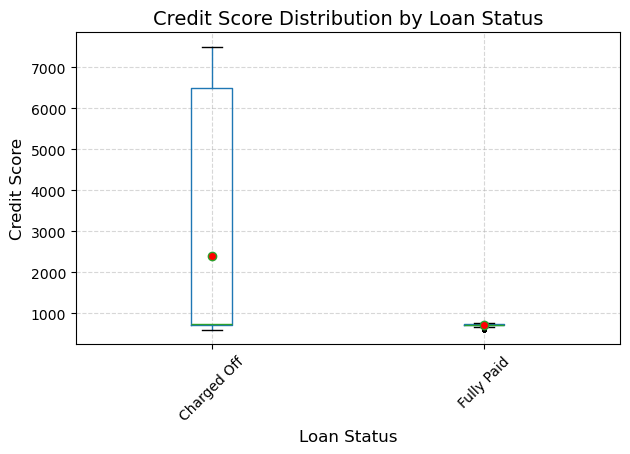

<Figure size 1000x600 with 0 Axes>

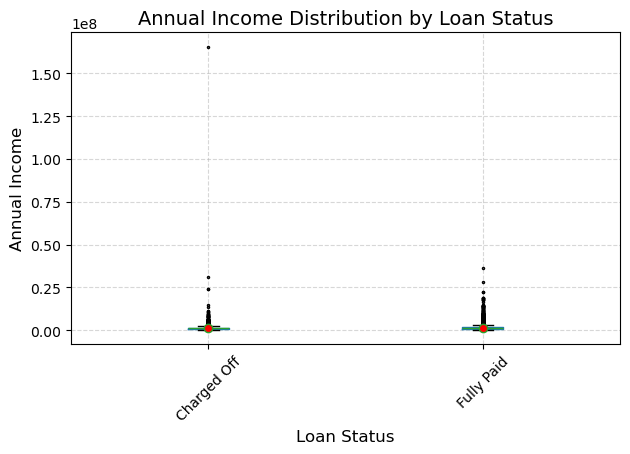

<Figure size 1000x600 with 0 Axes>

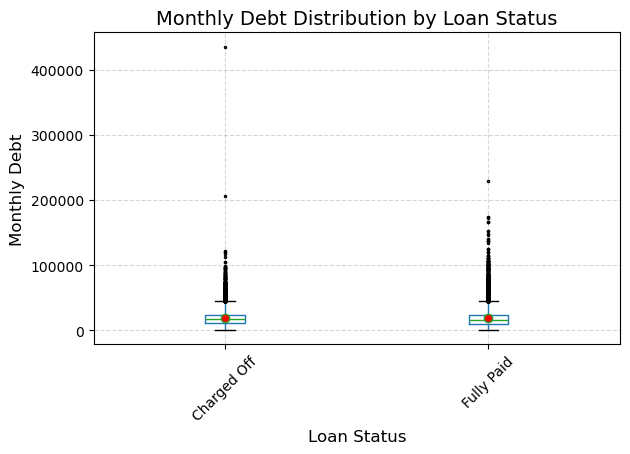

<Figure size 1000x600 with 0 Axes>

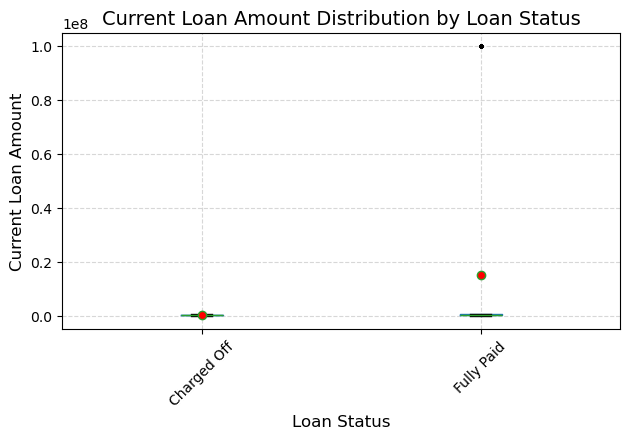

In [18]:
key_cols = [c for c in ["Credit Score", "Annual Income", "Monthly Debt", "Current Loan Amount"] 
            if c in df_clean.columns]
for col in key_cols:
    plt.figure(figsize=(10,6))
    df_clean.boxplot(column=col , by="Loan Status", showmeans=True, meanprops=dict(marker='o', markerfacecolor='red', markersize=6),flierprops=dict(marker='.' , markersize=3))
    plt.title(f"{col} Distribution by Loan Status",fontsize=14)
    plt.suptitle("")
    plt.xlabel("Loan Status", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle="--" , alpha=0.5)
    plt.tight_layout()
    plt.show()

##### 

##### Where Fully Paid loans generally exhibit stronger financial characteristics, while Charged Off loans show comparatively weaker profiles and greater variability.

# ------------------------------------------------------------------------------

##### The objective of this setp is to analyze the correlation structure among numerical variables and identify strong linear relationship (|r|>0.4). This helps detect multicollinearity and understand how financial variables move together.

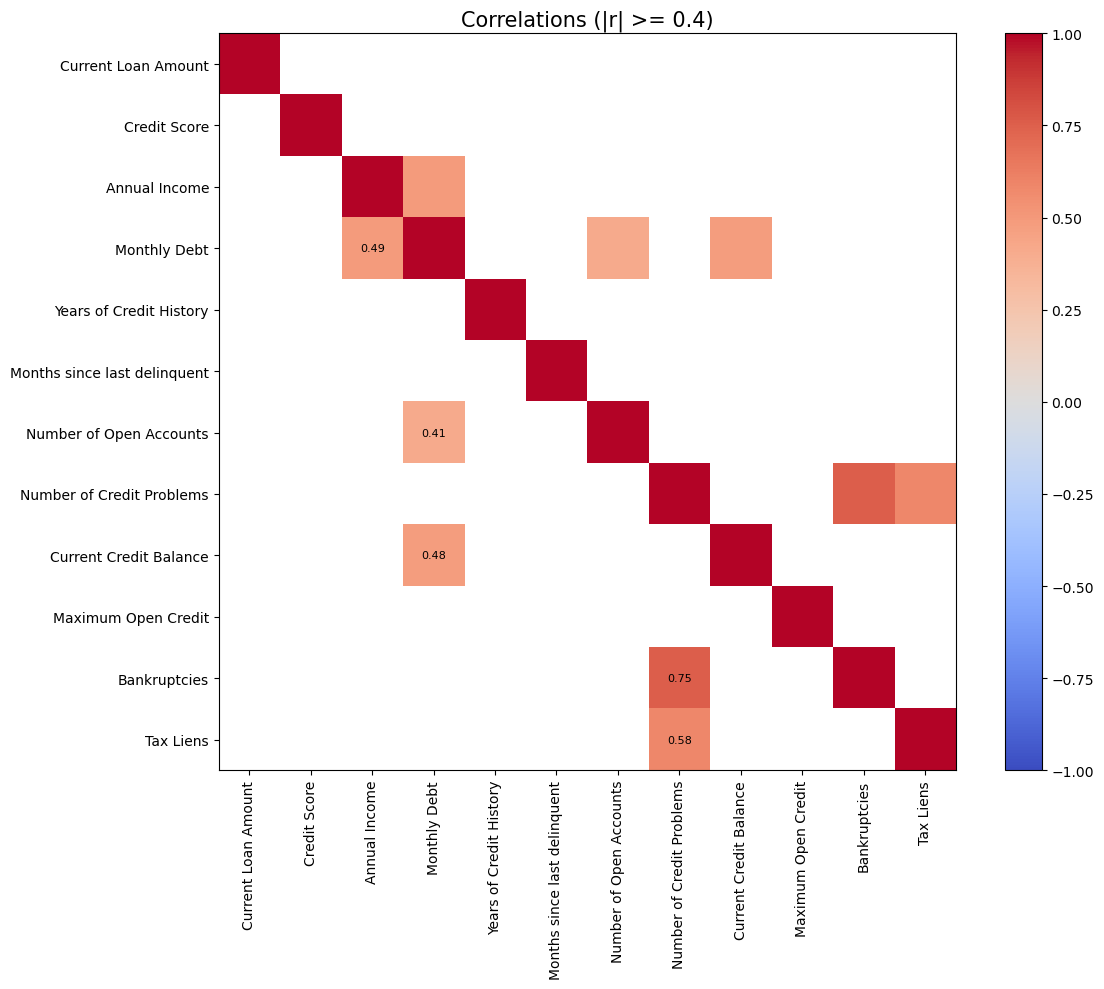

In [19]:
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
corr = df_clean[num_cols].corr()
threshold = 0.40
corr_strong = corr.copy()
corr_strong[abs(corr_strong) < threshold] = np.nan
mask = np.triu(np.ones_like(corr_strong, dtype=bool))
plt.figure(figsize=(12,10))
im = plt.imshow(corr_strong, cmap="coolwarm", vmin=-1, vmax=1)
for i in range(len(corr_strong.columns)):
    for j in range(len(corr_strong.columns)):
        if not mask[i, j] and not np.isnan(corr_strong.iloc[i, j]):
            plt.text(j, i,
                     f"{corr_strong.iloc[i, j]:.2f}",
                     ha="center",
                     va="center",
                     fontsize=8,
                     color="black")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title(f"Correlations (|r| >= {threshold})", fontsize=15)
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()
            
                     
     

##### The correlation heatmap shows moderate to strong positive relationships betweeen some financial variables. Notably, Annual Income and Monthly Dept (0.49), Monthly Dept and Current Credit Balance (0.48), and Bankruptcies and Number of Credit Problems (0.75) display meaningful asscociations. Overall, the dataset contains some correlated financial risk indicators, but no extreme multicollinearity across most features.

# -------------------------------------------------------------------------

##### The purpose of this step is to clean column names by removing leading and trailing whitespace characters. This prevents potential errors during column referencing, grouping, or feature selection.

In [20]:
df.columns=df.columns.str.strip()
display(df.columns)

Index(['Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Years in current job',
       'Home Ownership', 'Purpose', 'Monthly Debt', 'Years of Credit History',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens'],
      dtype='object')

##### After applying, all column names are standardized and free of extra spaces. The dataset structure remains the same, but column access is now safer and more consistent for subsequent analysis and modeling steps.

# ----------------------------------------------------------------------

##### The goal of this step is to clean categorical(object-type) variables by removing extra whitespace and standardizing missing value representations. This ensures consistency before encoding and modeling.

In [21]:
df=df.copy()
df.columns = df.columns.str.strip()
obj_cols=df.select_dtypes(include="object").columns
for c in obj_cols:
    df[c]=df[c].astype(str).str.strip().replace({"nan":np.nan,"":np.nan})
display(df[obj_cols].head())

,Customer ID,Loan Status,Term,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History
Loan ID,,,,,,,,
14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,Short Term,8 years,Home Mortgage,Home Improvements,5214.74,2.17.2026
4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,Short Term,10+ years,Home Mortgage,Debt Consolidation,33295.98,1.21.2026
4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,Short Term,8 years,Own Home,Debt Consolidation,29200.53,9.14.2026
77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,Long Term,3 years,Own Home,Debt Consolidation,8741.9,1.12.1900
d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,Short Term,5 years,Rent,Debt Consolidation,20639.7,1.6.2026


##### All object are now uniform formatted, text values are stripped of unnecessary spaces, and invalid string-based missing values are properly converted. The dataset is cleaner and ready for reliable categorical encoding and further preprocessing steps.

# ------------------------------------------------------------------------

##### The purpose of this step is to remove selected columns from the dataset. These variables are likely excluded due to high missingness, redundancy, difficulty in proper numerical conversion, or limited predictive contribution.

In [ ]:
col_to_drop="Years of Credit History"
if col_to_drop in df.columns:
    df=df.drop(columns=[col_to_drop])

In [23]:
col_to_drop="Purpose"
if col_to_drop in df.columns:
    df=df.drop(columns=[col_to_drop])

In [24]:
col_to_drop="Years in current job"
if col_to_drop in df.columns:
    df=df.drop(columns=[col_to_drop])

##### After this operation, the dataset becomes more streamlined and focused on the most reliable and model-relevant features. Removing these columns reduces noise, simplifies preprocessing, and helps improve model stability and interpretability.

# ------------------------------------------------------------------------------

##### The purpose of this step is to clean and standardize key financial variables by removing currency symbols and converting them into proper numeric formats. This ensures that these features can be used correctly in statistical analysis and machine learning models.

In [25]:
numeric=["Credit Score","Annual Income","Monthly Debt", "Current Loan Amount"]
for c in numeric:
    if c in df.columns:
        df[c]=(df[c].astype(str).str.replace(r"[\$]", "" , regex=True))
        df[c]=pd.to_numeric(df[c], errors="coerce")
display(df[numeric].dtypes)
display(df[numeric].describe())

Credit Score           float64
Annual Income          float64
Monthly Debt           float64
Current Loan Amount      int64
dtype: object

,Credit Score,Annual Income,Monthly Debt,Current Loan Amount
count,80846.000000,8.084600e+04,99995.000000,1.000000e+05
mean,1076.456089,1.378277e+06,18473.335269,1.176045e+07
std,1475.403791,1.081360e+06,12174.597353,3.178394e+07
min,585.000000,7.662700e+04,0.000000,1.080200e+04
25%,705.000000,8.488440e+05,10214.590000,1.796520e+05
50%,724.000000,1.174162e+06,16221.440000,3.122460e+05
75%,741.000000,1.650663e+06,24012.200000,5.249420e+05
max,7510.000000,1.655574e+08,435843.280000,1.000000e+08


##### All selected variablesare successfully converted to numeric types, and their descriptive statistics are now properly calculated. This confirms that the data is model-ready and suitable for further analysis.

# -------------------------------------------------------------------------

##### The purpose of this step is to quantify and rank missing values across all variables in the dataset. This helps identify which features require iputation, removal, or special handling before modelig.

In [26]:
display(df.isna().sum().sort_values(ascending=False).head(15))

Months since last delinquent    53141
Annual Income                   19154
Credit Score                    19154
Bankruptcies                      204
Tax Liens                          10
Monthly Debt                        5
Maximum Open Credit                 2
Home Ownership                      0
Term                                0
Loan Status                         0
Current Loan Amount                 0
Customer ID                         0
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
dtype: int64

##### The dataset is largely complete, but a few financially important cariables contain substantial missing data.

# --------------------------------------------------------------------------

##### The purpose of this step is to convert the categorical target variable "Loan Status" into a numerical format suitable for machine learning models.

In [27]:
target="Loan Status"
mapping={"Fully Paid":0 , "Charged Off":1}
df["target"] = df[target].map(mapping)
df = df.dropna(subset=["target"])
df["target"] = df["target"].astype(int)
display(df["target"].value_counts())

target
0    77361
1    22639
Name: count, dtype: int64

##### The target variable has been successfully prepared for modeling.

# -----------------------------------------------------------------------------

##### The purpose of this step is to prepare a clean, fully numeric feature matrix by removing irrelevant columns and encoding categorical variables so the dataset becomes suitable for machine learning models.

In [29]:
X = df.drop(columns=[c for c in ["Loan Status", "target"] if c in df.columns], errors="ignore")
id_cols = [c for c in X.columns if "id" in c.lower()]
X = X.drop(columns=id_cols, errors="ignore")
high_card_cols = [
    c for c in X.select_dtypes(include="object").columns
    if X[c].nunique() > 50
]

X = X.drop(columns=high_card_cols, errors="ignore")

for c in X.select_dtypes(include="object").columns:
    X[c] = X[c].fillna("unknown")

X_encoded = pd.get_dummies(X, drop_first=True)
display(X_encoded.head())

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens,Term_Short Term,Home Ownership_Home Mortgage,Home Ownership_Own Home,Home Ownership_Rent
Loan ID,,,,,,,,,,,,,,,
14dd8831-6af5-400b-83ec-68e61888a048,445412,709.0,1167493.0,5214.74,NaN,6,1,228190,416746.0,1.0,0.0,True,True,False,False
4771cc26-131a-45db-b5aa-537ea4ba5342,262328,NaN,NaN,33295.98,8.0,35,0,229976,850784.0,0.0,0.0,True,True,False,False
4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,99999999,741.0,2231892.0,29200.53,29.0,18,1,297996,750090.0,0.0,0.0,True,False,True,False
77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,347666,721.0,806949.0,8741.90,NaN,9,0,256329,386958.0,0.0,0.0,False,False,True,False
d4062e70-befa-4995-8643-a0de73938182,176220,NaN,NaN,20639.70,NaN,15,0,253460,427174.0,0.0,0.0,True,False,False,True


##### Feature engineering and encoding are correctly compleeted. The dataset is now in a clean, model-ready format and suitable for predictive modeling.

In [30]:
df.columns

Index(['Customer ID', 'Loan Status', 'Current Loan Amount', 'Term',
       'Credit Score', 'Annual Income', 'Home Ownership', 'Monthly Debt',
       'Months since last delinquent', 'Number of Open Accounts',
       'Number of Credit Problems', 'Current Credit Balance',
       'Maximum Open Credit', 'Bankruptcies', 'Tax Liens', 'target'],
      dtype='object')

# LOGISTIC REGRESSION

##### Logistic Regression is used as a baseline classifiation model to predict credit risk.

# --------------------------------------------------------------------------------------------

##### The purpose of this step is to import the required Python libraries for data processing, visualization, and machine learning model implementation.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import(accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, roc_auc_score, roc_curve)

##### The objective of this step is:
##### To divide the dataset into training and testing subsets
##### To handle missing values in a statistically sound manner
##### To prevent data leakage during preprocessing

In [37]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.20, random_state=42)
train_median=X_train.median(numeric_only=True)
X_train=X_train.fillna(train_median)
X_test=X_test.fillna(train_median)
print(X_train.isna().sum().sum(), X_test.isna().sum().sum())


0 0


##### This confirms that:
##### No missing values remain in either training or testing sets.
##### The dataset is fully compatible with Logistic Regression.

# -------------------------------------------------------------------------------------

##### The objective of this step is to:
##### Train a Logistic Regression classifier
##### Evulate its performance on the available dataset
##### Establish a baseline model performance

In [38]:
X=X_encoded.copy()
y=df["target"].copy()
X=X.fillna(X.median())
logmodel=LogisticRegression(max_iter=2000)
logmodel.fit(X,y)
print(logmodel.score(X,y))

0.81909


##### This model achieves:
##### Training accuracy = 81.9%
##### This indicates that the model correctly classifies approximately 82% of observations in the dataset.
##### Reasonable for logistic regression.

# ---------------------------------------------------------------------------------

##### The objective of this step is to evulate the Logistic Regression model on unseen test data and assess its generalization performance.


In [39]:
X=X_encoded.copy()
y=df["target"].copy()

y_pred= logmodel.predict(X_test)
y_prob= logmodel.predict_proba(X_test)[:, 1]
print("Train accuracy:", logmodel.score(X_train, y_train))
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification report:\n", classification_report(y_test, y_pred, zero_division=0))

Train accuracy: 0.8188375
Test accuracy: 0.82005
Precision: 1.0
Recall: 0.20569410726109028
ROC-AUC: 0.727078936280803

Classification report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90     15469
           1       1.00      0.21      0.34      4531

    accuracy                           0.82     20000
   macro avg       0.91      0.60      0.62     20000
weighted avg       0.85      0.82      0.77     20000



##### The Logistic Regression model demonstrates stable generalization with similar train and test accuracy (82%) and acceptable discrimination power (ROC-AUC=0.73);however, despite very high precision (1.00), it captures only about 21% of high-risk borrowes(low recall), indicating that the model is conservative and biased toward the majority(low-risk) class, which limits its effectiveness in credit risk detection.

# ------------------------------------------------------------------------------------

##### The purpose of the confusion matrix analysis is to evaluate how well the Logistic Regression model distinguishes between low-risk(class 0) and high-risk(class 1) borrowers, and to identify the types of classification errors being made.

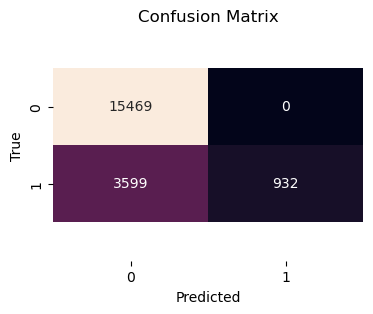

In [40]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
ax = sns.heatmap(cm, annot= True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

##### The model exhibits strong  overall accuracy, consistent performance between training and test data, and very high precision in identifying low-risk borrowers, demonstrating stable and reliable baseline classification performance within the credit risk framework.However, it also has a limited ability to identify a significant portion of high-risk borrowers.

# ----------------------------------------------------------------------------------

##### To evulate the model's ability to distinguish between low-risk and high-risk borrowers across different classification thresholds using the ROC curve and AUC metric.

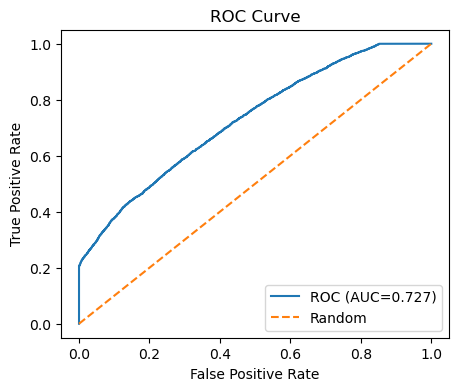

In [41]:
fpr, tpr, thr = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

##### The ROC curve lies clearly above the random classification line and yields an AUC of approximately 0.73, indicating that the model has a solid discriminatory capacity and performs significantly better than random guessing in separating risky and non-risky borrowers within the credit risk framework.

# RANDOM FOREST

##### Random Forest is used as a powerful enseble classification model to improve credit risk prediction.

# -----------------------------------------------------------------------------------

##### To import the necessary Python libraries for data manipulation, visulization,model building, and performance evaluation in the Random Forest classification process.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

##### To define the feature matrix (X) and target variable (y), ensuring that the model uses the correctly preprocessed dataset for classification.

In [43]:
X=X_encoded.copy() if "X_encoded" in globals() else df_clean.drop(columns=["target"]).copy()
y=df["target"].copy() if "target" in df.columns else df_clean["target"].copy()

##### The input features and target variable were properly assigned, allowing the Random Forest model to be trained on clean and structured data.

# ----------------------------------------------------------------------------------

##### To detect categorical(object-type) variables and convert them into numerical format using one-hot encoding so they can be used in the Random Forest model.

In [44]:
obj_cols= X.select_dtypes(include=["object"]).columns.tolist()
if len(obj_cols) > 0:
    X=pd.get_dummies(X, columns=obj_cols, drop_first=True)

##### All categorical variables were successfully transformed into numeric dummy variables, ensuring compatibility with the machine learning algorithm.

# ---------------------------------------------------------------------------------

##### To split the dataset into training and test sets while preserving the class distribution using stratification.

In [45]:
X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

##### The data was successfully divided into training(80%) and testing(20%) sets ensuring a balanced class distribution for reliable model evaluation.

# --------------------------------------------------------------------------------

##### To ensure that the training and test datasets have identical feature columns and to handle missing values by filling them with the median of the training data.

In [46]:
X_train, X_test= X_train.align(X_test, join="left", axis=1, fill_value=0)

In [47]:
med=X_train.median(numeric_only=True)
X_train=X_train.fillna(med)
X_test= X_test.fillna(med)

##### Both datasets were properly aligned with consistent feature structures, and missing values were successfully handled, preparing the data for stable Random Forest.

# -------------------------------------------------------------------------------

##### To initialize and train the Random Forest classifier with 200 decision trees,enabling ensemble-based credit risk prediction.

In [48]:
rf=RandomForestClassifier(
    n_estimators=200,
    random_state=0,
    oob_score=True,
    n_jobs=1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=1, oob_score=True,
                       random_state=0)

##### The Random Forest model was successfully trained on the training dataset and is now ready to generate predictions and evaluate classification performance.

# --------------------------------------------------------------------------------

##### To generate predictions on the test set and evaluate the Random Forest model using multiple performance metrics, including OOB accuracy, precision, recall,ROC-AUC, and the classification report.

In [49]:
y_pred=rf.predict(X_test)
y_prob=rf.predict_proba(X_test)[:,1]
print("OOB Accuracy :" , rf.oob_score_)
print("Test Accuracy :" , accuracy_score(y_test, y_pred))
print("Precision :" , precision_score(y_test, y_pred, zero_division=0))
print("Recall :" , recall_score(y_test, y_pred, zero_division=0))
print("ROC-AUC :" , roc_auc_score(y_test,y_prob))
print("\nClassification report:\n" , classification_report(y_test,y_pred, zero_division=0))

OOB Accuracy : 0.8185375
Test Accuracy : 0.8192
Precision : 0.8486238532110092
Recall : 0.24514134275618374
ROC-AUC : 0.8035458046177572

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.99      0.89     15472
           1       0.85      0.25      0.38      4528

    accuracy                           0.82     20000
   macro avg       0.83      0.62      0.64     20000
weighted avg       0.82      0.82      0.78     20000



##### The Random Forest model achieved strong overall accuarcy (82%) and good discrimination power (ROC-AUC=0.80). It performs very well in identifying the majority (low-risk) class, while showing moderate performance in detecting the minority (high-risk) class, as reflected by the lower recall for class 1.

# -------------------------------------------------------------------------------

##### To visualize the classification results of the Random Forest model using a confusion matrix in order to analyze correct and incorrect predictions.

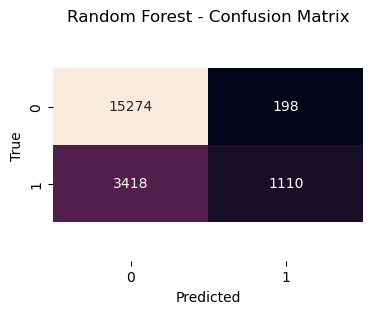

In [50]:
cm= confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
ax=sns.heatmap(cm, annot= True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest - Confusion Matrix")
bottom, top = ax.get_ylim()
ax.set_ylim(bottom+ 0.5, top - 0.5)
plt.show()

##### The model correctly classified 15,274 low-risk cases and 1,110 high-risk cases, with only 198 false positive , showing strong performance in identifying non-risk customers; however, 3,418 high-risk cases were misclassified as low-risk, indicating moderate sensitivity for the minority class despite overall solid accuracy.

# ------------------------------------------------------------------------------------

##### To evaluate the Random Forest model's discriminative power across all classification thresholds using the ROC curve and AUC metric.

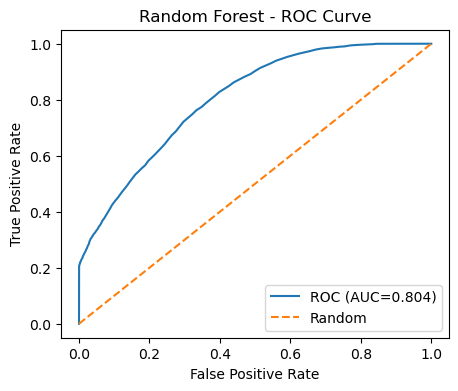

In [51]:
fbr, tpr,_=roc_curve(y_test,y_prob)
auc=roc_auc_score(y_test, y_prob)
plt.figure(figsize=(5,4))
plt.plot(fbr, tpr, label=f"ROC (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend(loc="lower right")
plt.show()


##### With an AUC 0.804, the Random Forest model demonstrates strong class separation capability and performs clearly better than random guessing, indicating reliable probability-based risk disceimination in the project.

# --------------------------------------------------------------------------------------------

##### To identify which features contribute most to the Random Forest model's prediction of loan risk using impurity-based feature importance scores.


Top 15 Feature Importances:
 Credit Score                    0.226422
Current Loan Amount             0.147516
Monthly Debt                    0.117486
Maximum Open Credit             0.117353
Current Credit Balance          0.116006
Annual Income                   0.094179
Number of Open Accounts         0.071425
Months since last delinquent    0.064658
Term_Short Term                 0.012069
Number of Credit Problems       0.009644
Bankruptcies                    0.006838
Home Ownership_Rent             0.004509
Home Ownership_Home Mortgage    0.004372
Home Ownership_Own Home         0.003956
Tax Liens                       0.003566
dtype: float64


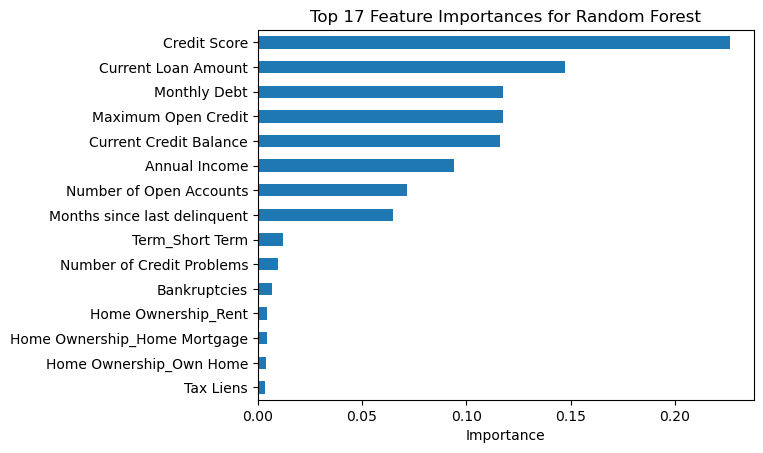

In [52]:
importances=pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
print("\nTop 15 Feature Importances:\n" , importances)

plt.figure()
importances.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.title("Top 17 Feature Importances for Random Forest")
plt.show()

##### The model relies primarily on Credit Score, Current Loan Amount, Monthly Dept, and other financial capacity indicators, confirm that creditworthiness and debt-related variables are the dominant drivers of risk prediction in the project.

# SUPPORT VECTOR MACHİNES

##### Support Vector Machine (SVM) is a predctive analytics algoritm that constructs an optimal hyperplane with maximum margin to seperate classes, and it is use for both classification and reggression problems.

# ------------------------------------------------------------------------------------

##### To imprort the neccesary libraries and modules required to build, train, and evulate a Support Vector Machine(SVM) model.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import(accuracy_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

##### This step prepares the datasetfor modeling by defining the feature matrix(X) and target variable(y), converting the target to numeric format, and encoding categorical variables using one-hot encoding so that machine learning algoritms can process the data properly.

In [54]:
X=X_encoded.copy() if "X_encoded" in globals() else df_clean.drop(columns=["target"]).copy()
y=df["target"].copy() if ("df" in globals() and "target" in df.columns) else df_clean ["target"].copy()

In [55]:
y= pd.to_numeric(y, errors="coerce").fillna(0).astype(int)

In [56]:
obj_cols=X.select_dtypes(include=["object"]).columns.tolist()
if len(obj_cols) > 0:
    X=pd.get_dummies(X, columns=obj_cols, drop_first=True)

##### The split the dataset into training and testing sets so that the predictive analytics algoritms can be trained on 80% of the data and evulated on the remaining 20%, while preserving the class distribution using strafication.

In [57]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

##### To standardize the feature cariables so taht they have been 0 and standard deviation 1.

In [59]:
scaler=StandardScaler()
X_train_std=scaler.fit_transform(X_train)
X_test_std=scaler.transform(X_test)

##### This ensures consistent feature scaling and improves model stability and performance.

# ------------------------------------------------------------------------------------

##### To ensure that the training and test featre sets have identical columns, handle missing values using median imputation, and verify data integrity before training the predictive analytics algoritm.

In [58]:
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
med=X_train.median(numeric_only=True)
X_train=X_train.fillna(med)
X_test=X_test.fillna(med)

print("Shapes | X_train:", X_train.shape, "X_test:", X_test.shape)
print("NaN for train and test:", int(X_train.isna().sum().sum()), int(X_test.isna().sum().sum()))
print("Class distribution:\n", pd.Series(y_train).value_counts())

Shapes | X_train: (80000, 15) X_test: (20000, 15)
NaN for train and test: 0 0
Class distribution:
 target
0    61889
1    18111
Name: count, dtype: int64


##### Confirms that the dataset correctly prepared and ready for model training.

# --------------------------------------------------------------------------------

##### To train a Support Vector Machine predictive analytics algoritm usning RBF kernel to classify loa status based on standarized features.

In [60]:
svm=SVC(C=1.0, kernel="rbf", gamma="scale", probability=True, random_state=42)
svm.fit(X_train_std, y_train)

SVC(probability=True, random_state=42)

##### The display SVC confirms that the model was successfully trained.

# -------------------------------------------------------------------------------------

##### To evulate the performance of the trained Support Vector Machine predictive analytics algoritm on the test dataset using classification performance metrics.

In [62]:
y_pred=svm.predict(X_test_std)
y_prob= svm.predict_proba(X_test_std)[:,1]
print("\nTrain Accuracy:", svm.score(X_train_std, y_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test,y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test,y_pred, zero_division=0))


Train Accuracy: 0.819225
Test Accuracy: 0.82005
Precision: 1.0
Recall: 0.20516784452296818
ROC-AUC: 0.6938332162671151

Classification Report:
               precision    recall  f1-score   support

           0       0.81      1.00      0.90     15472
           1       1.00      0.21      0.34      4528

    accuracy                           0.82     20000
   macro avg       0.91      0.60      0.62     20000
weighted avg       0.85      0.82      0.77     20000



##### The SVM model achieves good overall accuracy (82%).

# ----------------------------------------------------------------------------------

##### The analyze the detailed classification performance of the SVM predictive analytics algoritm by examining how many observations were correctly and incorrectly classified for each class.

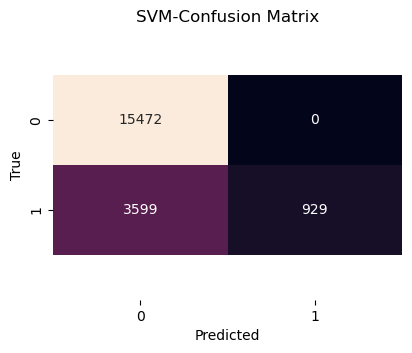

In [63]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5,3.5))
ax=sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SVM-Confusion Matrix")
bottom, top= ax.get_ylim()
ax.set_ylim(bottom+ 0.5, top-0.5)
plt.show()

##### The SVM model is safe but no aggressive in detecting risk.

# --------------------------------------------------------------------------------------

##### To evulate the overall classification power of SVM predictive analytics algorithm across all possible decision thresholds using the ROC curve and AUC metric.

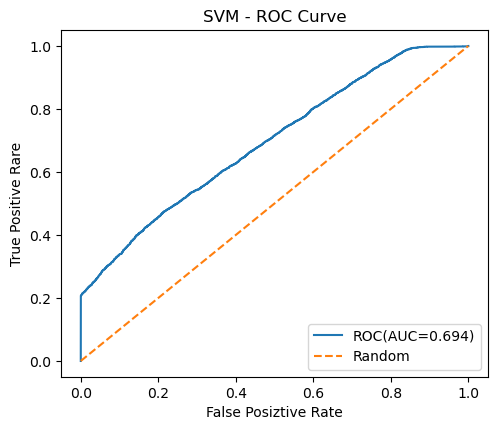

In [67]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc=roc_auc_score(y_test,y_prob)
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f"ROC(AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", label="Random")
plt.xlabel("False Posiztive Rate")
plt.ylabel("True Positive Rare")
plt.title("SVM - ROC Curve")
plt.legend(loc="lower right")
plt.show()

##### The SVM model has acceptable but limited predictive strength; it can distinguish risky borrowers better than chance, but its ability to separate is moderate.

# -------------------------------------------------------------------------------------------

# -------------------------------------------------------------------------------------------

#### All three predictive analytics algoritms produced similar overall accuracy levels (approximately 82%). However, their discriminative power differed:
#### Random Forest delivered the strongest overall performance with ROC-AUC = 0.80, demonstrating superior ability to seperate risky and non-risky borrowers and effectively capturing nonlinear replationships in the data.
#### Logistic Regression produced stable and interpretable results with competitive accuracy but showed weaker performance compared to Random Forest in handling complex patterns.
#### Support Vector Machine (SVM) achieved similar accuracy but lower ROC-AUC=(0.69), indicating comparatively weaker class separation performance.
#### Across all models, performance on the majority class (Fully Paid) was significantly stronger than on the minority class (Charged Off),as observed from recall and confusion matrix results.
#### Overall, Random Forest emerged as the most effective predictive analytics algorithm in this project, providing the best balance between accuracy, discrimination capability, and overall classification stability for credit risk modeling.